In [14]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.ticker import MultipleLocator
from inference import HiddenMarkovModel
from utils import load_data

## Part 1 visuals

In [15]:
def illustrate_hidden_Markov_model(X, T, n, degree=4):
    """Illustrate the hidden Markov model generated"""
    t = np.arange(1, T + 1, dtype=float)
    x_mean = X.mean(axis=1)
    y_fit = np.polyval(np.polyfit(t, x_mean, deg=degree), t)

    ymax = max(10, 5 * math.ceil((X.max() + 1) / 5))

    fig = plt.figure(figsize=(10, 0.72 * n + 2.8), facecolor="#ffffff")
    outer = fig.add_gridspec(2, 1, height_ratios=[n, 1.35], hspace=0.28)
    upper = outer[0].subgridspec(n, 1, hspace=0.20)

    axes = [fig.add_subplot(upper[0, 0])]
    for i in range(1, n):
        axes.append(fig.add_subplot(upper[i, 0], sharex=axes[0]))

    ax_mean = fig.add_subplot(outer[1, 0], sharex=axes[0])

    def style_axis(ax):
        ax.set_facecolor("#ebebeb")
        ax.set_axisbelow(True)
        ax.grid(True, which="major", color="#d0d0d0", linewidth=1.0)
        ax.grid(True, which="minor", color="#f3f3f3", linewidth=0.8)
        ax.minorticks_on()
        ax.xaxis.set_major_locator(MultipleLocator(25))
        ax.xaxis.set_minor_locator(MultipleLocator(5))
        for spine in ax.spines.values():
            spine.set_color("#444444")
            spine.set_linewidth(0.8)

    for i, ax in enumerate(axes, start=1):
        ax.plot(t, X[:, i - 1], "o-", color="black", linewidth=1.1, markersize=3.6)
        ax.set_ylim(-0.2, ymax + 0.5)
        ax.yaxis.set_major_locator(MultipleLocator(5))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        style_axis(ax)

        if i < n:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("t", fontsize=14)

        ax.text(
            1.02,
            0.5,
            f"{i}",
            transform=ax.transAxes,
            rotation=270,
            va="center",
            ha="center",
            fontsize=12,
            bbox=dict(
                boxstyle="square,pad=0.55",
                facecolor="#d9d9d9",
                edgecolor="#444444",
                linewidth=0.8,
            ),
            clip_on=False,
        )

    ax_mean.plot(t, x_mean, "o-", color="black", linewidth=1.1, markersize=3.6)
    ax_mean.plot(t, y_fit, color="blue", linewidth=2.8)
    style_axis(ax_mean)
    ax_mean.set_ylabel(r"Mean of $X_t$", fontsize=14)
    ax_mean.set_xlabel("t", fontsize=14)

    fig.text(0.06, 0.62, r"$X_t$", rotation=90, va="center", ha="center", fontsize=18)
    fig.subplots_adjust(left=0.10, right=0.93, top=0.90, bottom=0.08)

    plt.show()


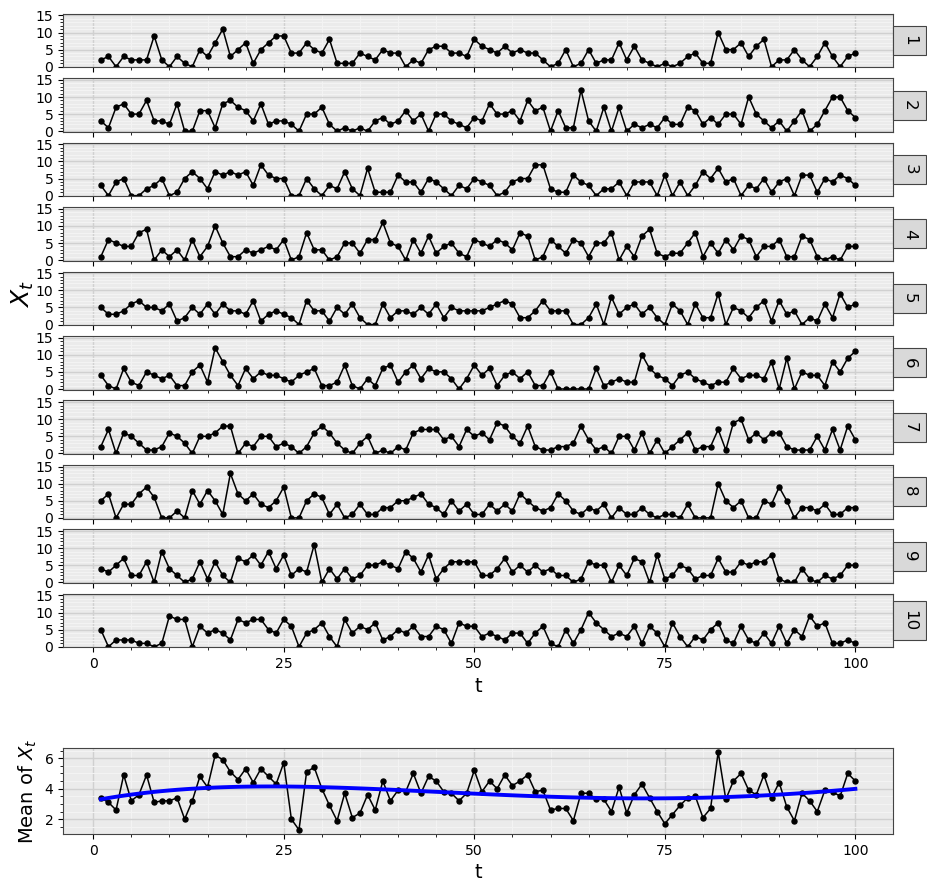

In [16]:
# Execute part 1 visuals
T, n = 100, 10
params = {"alpha": 0.9, "beta": 0.2, "gamma": 0.1, "lam0": 1, "lam1": 5}
HMM = HiddenMarkovModel(**params)
_, _, X = HMM.simulate(T, n)
C, Z, X = HMM.simulate(T, n)
illustrate_hidden_Markov_model(X, T, n)

## Visuals part 2

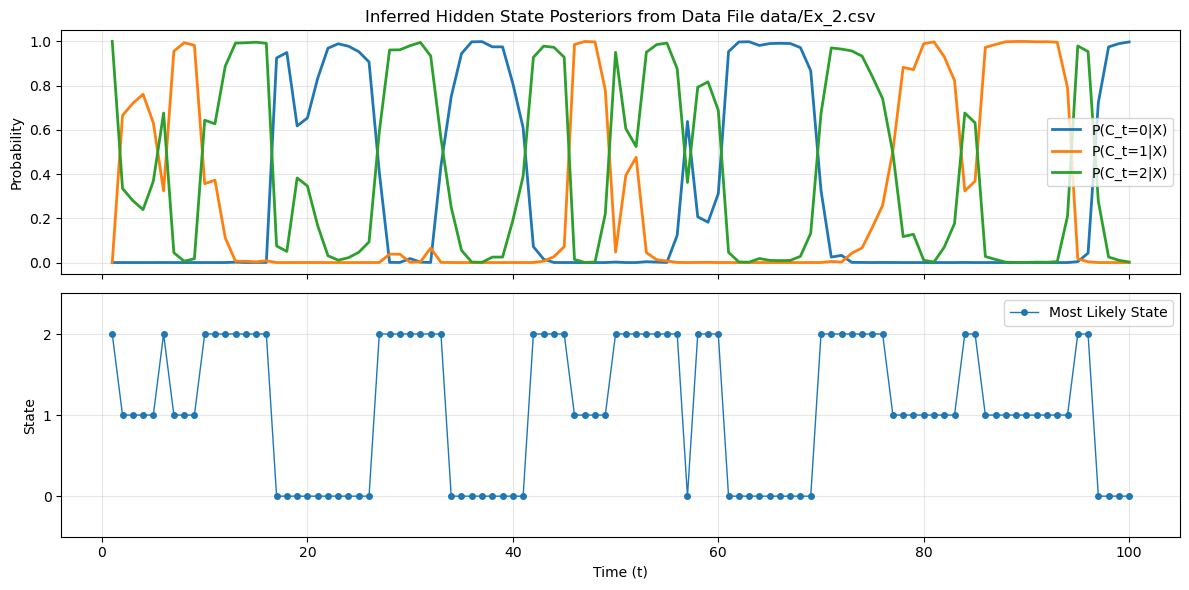

INFERENCE RESULTS ON DATA FILE
Data shape: T=100, n=8

State transition proportions:
  State 0: 0.320
  State 1: 0.270
  State 2: 0.410

Mean posterior probabilities:
  P(C_t=0|X): 0.3112
  P(C_t=1|X): 0.2788
  P(C_t=2|X): 0.4099


In [ ]:
# Load data from file and run inference
file_path = "data/Ex_2.csv"
df_data, t_data, X_data, T_data, n_data = load_data(file_path)
T, n = 100, 10
params = {"alpha": 0.9, "beta": 0.2, "gamma": 0.1, "lam0": 1, "lam1": 5}
HMM = HiddenMarkovModel(**params)

# Run inference on the loaded data
post_c_data, post_z_data = HMM.inference(X_data)

# Visualize the inferred hidden state C_t
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot 1: Posterior probabilities for each state
for c in range(3):
    axes[0].plot(t_data, post_c_data[:, c], label=f"P(C_t={c}|X)", linewidth=2)
axes[0].set_ylabel("Probability")
axes[0].set_title(f"Inferred Hidden State Posteriors from Data File {file_path}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Most likely state at each time
most_likely_state = np.argmax(post_c_data, axis=1)
axes[1].plot(t_data, most_likely_state, marker="o", markersize=4, linewidth=1, label="Most Likely State")
axes[1].set_ylabel("State")
axes[1].set_xlabel("Time (t)")
axes[1].set_ylim(-0.5, 2.5)
axes[1].set_yticks([0, 1, 2])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 60)
print("INFERENCE RESULTS ON DATA FILE")
print("=" * 60)
print(f"Data shape: T={T_data}, n={n_data}")
print(f"\nState transition proportions:")
for c in range(3):
    print(f"  State {c}: {np.mean(most_likely_state == c):.3f}")
print(f"\nMean posterior probabilities:")
for c in range(3):
    print(f"  P(C_t={c}|X): {np.mean(post_c_data[:, c]):.4f}")

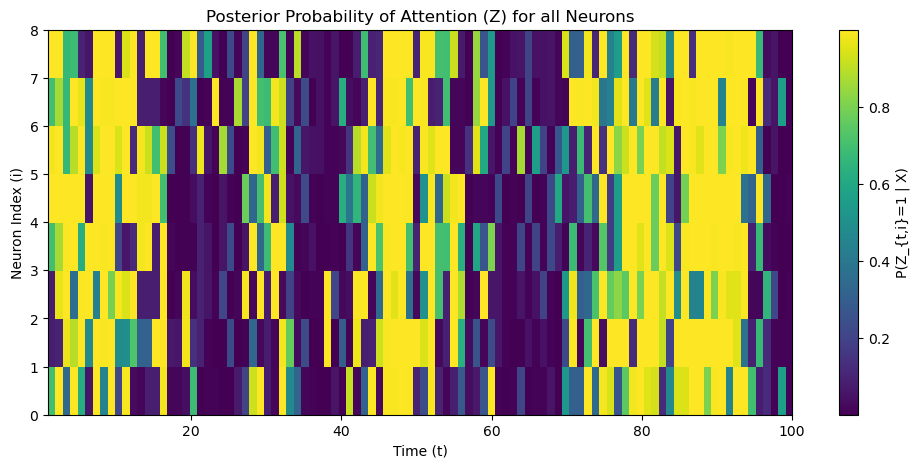

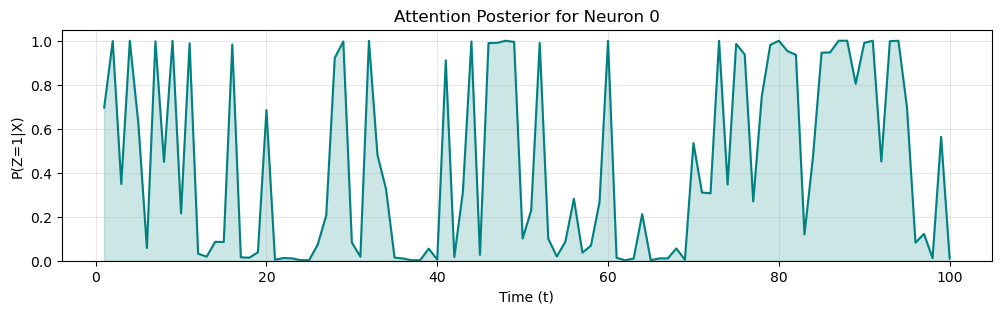

In [18]:
# Visualize the inferred attention Z_t,i
plt.figure(figsize=(12, 5))
# We transpose to have Neurons on y-axis and Time on x-axis
plt.imshow(post_z_data.T, aspect="auto", origin="lower", extent=[t_data[0], t_data[-1], 0, n_data])
plt.colorbar(label="P(Z_{t,i}=1 | X)")
plt.xlabel("Time (t)")
plt.ylabel("Neuron Index (i)")
plt.title("Posterior Probability of Attention (Z) for all Neurons")
plt.show()

# Optional: Plot a single neuron's attention over time for clarity
plt.figure(figsize=(12, 3))
neuron_idx = 0  # Change this to see different neurons
plt.plot(t_data, post_z_data[:, neuron_idx], color="teal")
plt.fill_between(t_data, post_z_data[:, neuron_idx], alpha=0.2, color="teal")
plt.title(f"Attention Posterior for Neuron {neuron_idx}")
plt.ylabel("P(Z=1|X)")
plt.xlabel("Time (t)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()